# Прогнозирование страхового случая по изображениям

### Введение

В данном проекте рассмотрим задачу для страховой компании. В качестве основного источника данных используется датасет [Fast, Furious and Insured](https://www.kaggle.com/datasets/infernape/fast-furious-and-insured). Он содержит изображения автомобилей и табличную разметку. Мы будем рассматривать изображения

С точки зрения машинного обучения задачу на изображениях формулируем следующим образом:

* **Тип задачи:** бинарная классификация изображений
* **Объект наблюдения:** фотография автомобиля
* **Входные данные:** RGB-изображение автомобиля
* **Целевая переменная:** `Condition`
* **Выход модели:** вероятность принадлежности изображения к классу поврежденного автомобиля

В рамках проекта будем интерпретировать целевую переменную следующим образом:

|Значение целевой переменной|Интерпретация|
|----|----|
|`0`|автомобиль без видимых повреждений |
|`1`|автомобиль с видимыми повреждениями|

Перед обучением моделей необходимо проверить фактические значения `Condition` в датасете

Для решения задачи классификации изображений используются сверточные нейронные сети. Это связано с тем, что изображение имеет пространственную структуру, т.к. соседние пиксели образуют локальные визуальные паттерны, например в нашем случая края, контуры, царапины, вмятины и деформации кузова.

В материалах лекций по сверточным нейронным сетям мы рассматриваем изображение рассматривается как тензор размера W на H на C, где W = ширина, H = высота, а C = количество каналов. Для RGB-изображений обычно используется три канала red, green и blue. Также мы помним, что операция свертки позволяет получать карты признаков, т. е. находить локальные паттерны на изображении с помощью обучаемых фильтров.

Поэтому для данной задачи будут использоваться CNN архитектуры, которые лучше подходят для обработки изображений, чем обычные полносвязные сети

### Подготовка

Перед загрузкой данных и обучением моделей зададим общие параметры эксперимента. Все сравниваемые архитектуры должны обучаться в одинаковых условиях

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from pathlib import Path

Зафиксируем random seed, чтобы разбиение данных, случайные операции и инициализация весов модели были более воспроизводимыми

In [3]:
import random

random_state = 42
random.seed(random_state)
np.random.seed(random_state)
torch.manual_seed(random_state)
if torch.cuda.is_available():
    torch.cuda.manual_seed(random_state)
    torch.cuda.manual_seed_all(random_state)

Наш состав датасета который мы будем использовать:
- train.csv - таблица с обучающей разметкой
- trainImages - папка с обучающими изображениями

Так как задача на изображениях решается как задача компьютерного зрения, нам необходимо связать строки таблицы train.csv с соответствующими файлами из папки trainImages

In [4]:
DATA_DIR = Path('Fast_Furious_Insured')

In [5]:
list(DATA_DIR.iterdir())

[PosixPath('Fast_Furious_Insured/testImages'),
 PosixPath('Fast_Furious_Insured/trainImages'),
 PosixPath('Fast_Furious_Insured/test.csv'),
 PosixPath('Fast_Furious_Insured/train.csv'),
 PosixPath('Fast_Furious_Insured/sample_submission.csv')]

In [6]:
train_data = pd.read_csv(DATA_DIR / 'train.csv')
test_data = pd.read_csv(DATA_DIR / 'test.csv')

In [7]:
train_data.head()

,Image_path,Insurance_company,Cost_of_vehicle,Min_coverage,Expiry_date,Max_coverage,Condition,Amount
0,img_4513976.jpg,BQ,41500.0,1037.5,2026-12-03,36142.68,0,0.0
1,img_7764995.jpg,BQ,50700.0,1267.5,2025-07-10,12753.00,1,6194.0
2,img_451308.jpg,A,49500.0,1237.5,2022-08-11,43102.68,0,0.0
3,img_7768372.jpg,A,33500.0,837.5,2022-08-02,8453.00,1,7699.0
4,img_7765274.jpg,AC,27600.0,690.0,2026-05-01,6978.00,1,8849.0


In [8]:
train_data.shape

(1399, 8)

In [9]:
test_data.shape

(600, 6)

In [10]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1399 entries, 0 to 1398
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Image_path         1399 non-null   object 
 1   Insurance_company  1399 non-null   object 
 2   Cost_of_vehicle    1310 non-null   float64
 3   Min_coverage       1310 non-null   float64
 4   Expiry_date        1399 non-null   object 
 5   Max_coverage       1310 non-null   float64
 6   Condition          1399 non-null   int64  
 7   Amount             1388 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 87.6+ KB


In [11]:
train_data.isna().sum()

Image_path            0
Insurance_company     0
Cost_of_vehicle      89
Min_coverage         89
Expiry_date           0
Max_coverage         89
Condition             0
Amount               11
dtype: int64

In [12]:
train_data.duplicated().sum()

np.int64(0)

После загрузки таблиц видно, что обучающая выборка содержит 1399 объектов и 8 столбцов, а тестовая выборка содержит 600 объектов и 6 столбцов.

В обучающей таблице присутствуют следующие столбцы:

- `Image_path` - имя файла изображения автомобиля
- `Insurance_company` - страховая компания
- `Cost_of_vehicle` - стоимость автомобиля
- `Min_coverage` - минимальное покрытие
- `Expiry_date` - дата окончания страхового покрытия
- `Max_coverage` - максимальное покрытие
- `Condition` - состояние автомобиля
- `Amount` - сумма страховой выплаты

Для задачи компьютерного зрения используем два ключевых столбца:

- `Image_path`, так как он связывает строку таблицы с изображением из папки `trainImages`
- `Condition`, так как эта переменная будет использоваться как целевая переменная для классификации изображения

В столбцах `Cost_of_vehicle`, `Min_coverage`, `Max_coverage` и `Amount` есть пропуски. Однако для текущей CV задачи это нам не является критичным, потому что столбцы `Image_path` и `Condition` не содержат пропущенных значений

### Анализ целевой переменной

Перед нами задача - `Image Classification`, то есть определение класса изображения. В нашем случае класс изображения задается переменной `Condition`.

Перед обучением модели необходимо проверить:
- какие значения принимает `Condition`
- сколько объектов относится к каждому классу
- есть ли дисбаланс классов
- как классы связаны с изображениями и страховой выплатой

Проверим уникальные значения переменной `Condition`, чтобы убедиться, что задача действительно является бинарной классификацией

In [13]:
train_data['Condition'].unique()

array([0, 1])

Посчитаем количество объектов в каждом классе, посмотрим на сбалансированность 

In [14]:
train_data['Condition'].value_counts()

Condition
1    1300
0      99
Name: count, dtype: int64

In [15]:
train_data['Condition'].value_counts(normalize=True)

Condition
1    0.929235
0    0.070765
Name: proportion, dtype: float64

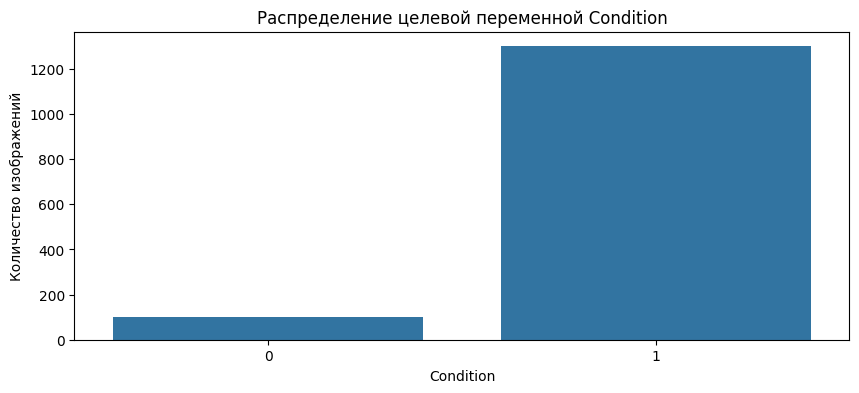

In [16]:
plt.figure(figsize=(10, 4))
sns.countplot(data=train_data, x='Condition')
plt.title('Распределение целевой переменной Condition')
plt.xlabel('Condition')
plt.ylabel('Количество изображений')
plt.show()

Да, видим, что переменная `Condition` принимает все же два значения: `0` и `1`, поэтому задачу на изображениях можно формулировать как задачу бинарной классификации.

Распределение классов оказалось все же несбалансированным:

- `Condition = 1`: 1300 изображений, около 92.9% выборки
- `Condition = 0`: 99 изображений, около 7.1% выборки

Классы явно представлены в данных неравномерно. Если модель будет всегда предсказывать класс `1`, она уже получит accuracy около 92.9%, но такая модель не будет полезной, потому что она не научится различать оба состояния автомобиля.

Поэтому в дальнейшем accuracy нельзя нам будет использовать как единственную метрику качества. Для оценки моделей дополнительно будем использовать precision, recall, F1-score, ROC-AUC и confusion matrix. Особенно важно будет анализировать качество по классу `Condition = 0`

Также не забудем, при разбиении данных на train/validation/test нужно использовать стратификацию по `Condition`, чтобы доли классов в подвыборках оставались похожими на исходное распределение

### Визуальная проверка классов

Теперь проверим, что именно означают значения `Condition = 0` и `Condition = 1` на изображениях. Откроем несколько изображений из каждого класса и визуально проверим, отличаются ли они по наличию повреждений

Посмотрим на первое изображение датасета

In [17]:
example_image = plt.imread(DATA_DIR / 'trainImages' / train_data.iloc[0, 0])

In [18]:
example_image.shape

(418, 630, 3)

In [19]:
example_image.dtype

dtype('uint8')

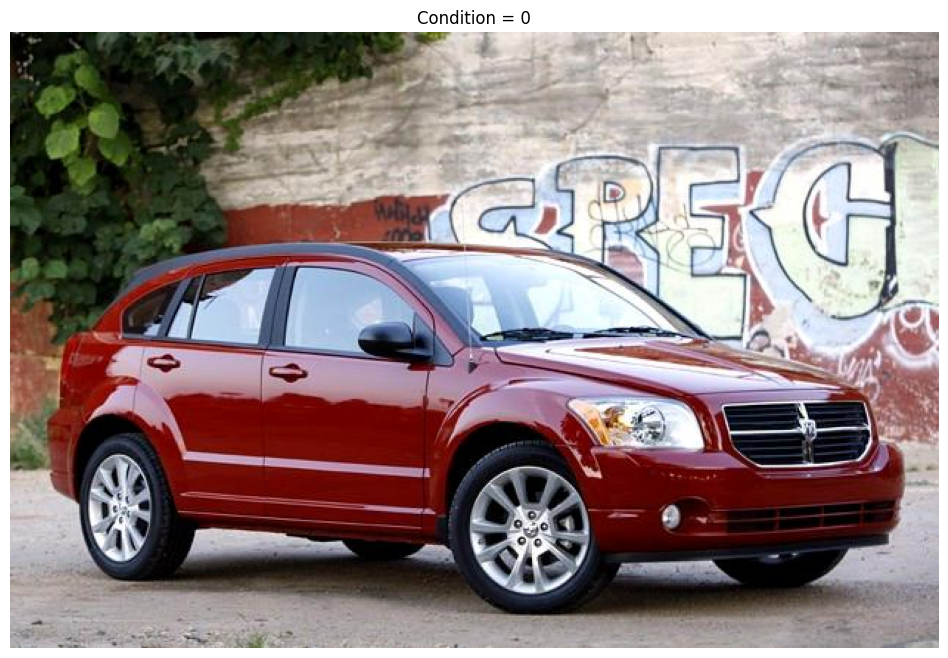

In [20]:
plt.figure(figsize=(12, 8))
plt.imshow(example_image)
plt.title(f'Condition = {train_data.iloc[0, -2]}')
plt.axis('off')
plt.show()

Да, видно, что нет каких-то повреждений

Напишем функцию для вывода примеров

In [21]:
def show_images_by_condition(data, condition_value, n_images=6, random_state=random_state):
    sample_cond = data[data['Condition'] == condition_value].sample(n_images, random_state=random_state)
    image_paths = sample_cond['Image_path'].tolist()
    plt.figure(figsize=(12, 8))
    for i in range(len(image_paths)):
        image = plt.imread(DATA_DIR / 'trainImages' / image_paths[i])
        plt.subplot(2, 3, i+1)
        plt.imshow(image)
        plt.title(f'{image_paths[i]}.Condition = {condition_value}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

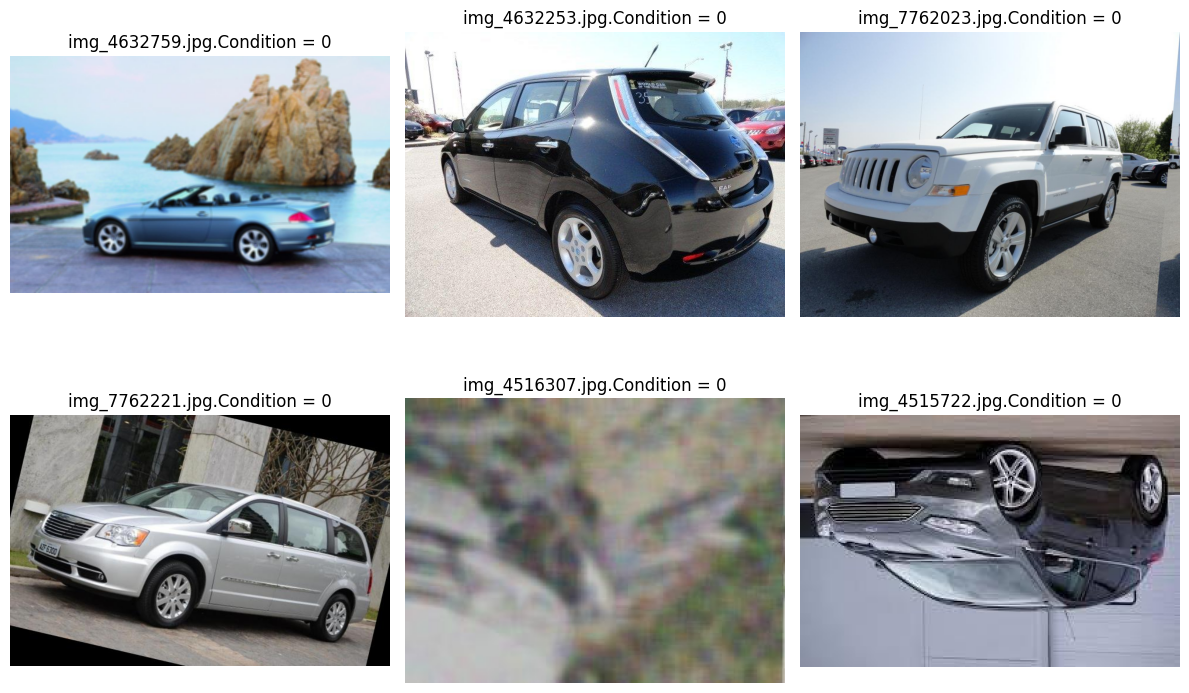

In [22]:
show_images_by_condition(train_data, condition_value=0, n_images=6)

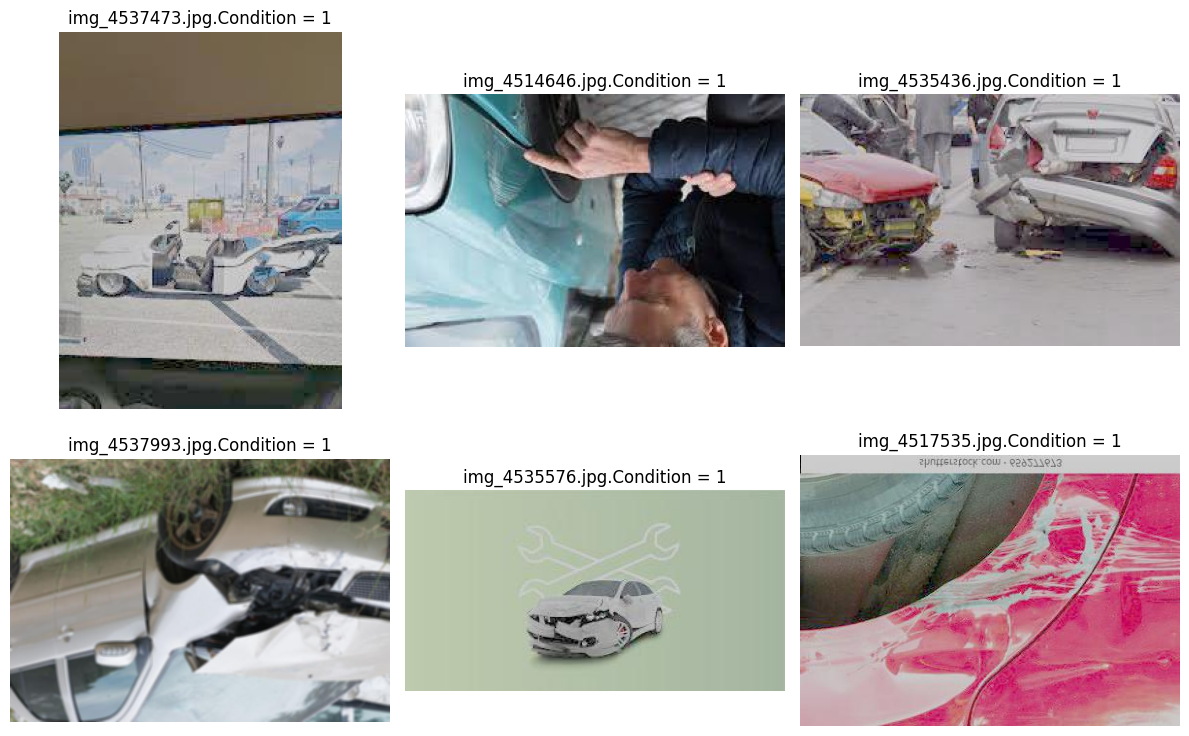

In [23]:
show_images_by_condition(train_data, condition_value=1, n_images=6)

Видно, что переменная `Condition` связана с наличием повреждений автомобиля.

Для класса `Condition = 0` в выборке в основном представлены автомобили без заметных повреждений. Для класса `Condition = 1` в большинстве примеров видны повреждения автомобиля, по типу деформация кузова, следы аварии, вмятины или другие визуальные признаки страхового случая.

Переменную `Condition` можно использовать как целевую переменную для наших задач.

При этом мы видим некоторые проблемы качества данных:
- часть изображений имеет нестандартную ориентацию
- некоторые изображения размыты или плохо различимы
- фотографии отличаются по масштабу, ракурсу, освещению и фону

Эти особенности важно учитывать при дальнейшем обучении модели

### Проверка изображений

Нам необходимо убедиться, что все изображения из столбца `Image_path` действительно существуют в папке `trainImages`. Это важно, потому что при обучении модели `Dataset` будет по каждой строке таблицы открывать соответствующее изображение. Если хотя бы часть файлов отсутствует или указана неверно, обучение прервется с ошибкой

In [24]:
image_data = train_data[['Image_path', 'Condition']].copy()
image_data.head()

,Image_path,Condition
0,img_4513976.jpg,0
1,img_7764995.jpg,1
2,img_451308.jpg,0
3,img_7768372.jpg,1
4,img_7765274.jpg,1


In [25]:
image_data['full_image_path'] = image_data['Image_path'].apply(lambda x: DATA_DIR / 'trainImages' / x)
image_data.head()

,Image_path,Condition,full_image_path
0,img_4513976.jpg,0,Fast_Furious_Insured/trainImages/img_4513976.jpg
1,img_7764995.jpg,1,Fast_Furious_Insured/trainImages/img_7764995.jpg
2,img_451308.jpg,0,Fast_Furious_Insured/trainImages/img_451308.jpg
3,img_7768372.jpg,1,Fast_Furious_Insured/trainImages/img_7768372.jpg
4,img_7765274.jpg,1,Fast_Furious_Insured/trainImages/img_7765274.jpg


In [26]:
image_data['file_exists'] = image_data['full_image_path'].apply(lambda x: x.exists())
image_data['file_exists'].value_counts()

file_exists
True    1399
Name: count, dtype: int64

Все изображения, указанные в столбце `Image_path`, найдены в папке `trainImages`. Значит, таблица с разметкой корректно связана с файлами изображений, и можно переходить к проверке размеров и форматов изображений

Перед обучением CNN необходимо проверить размеры изображений. В датасете изображения могут иметь разную ширину и высоту, но нейронная сеть обычно получает батчи тензоров одинакового размера Поэтому перед подачей в модель изображения будут приводиться к единому размеру. Однако сначала нужно посмотреть исходное распределение размеров, чтобы понимать, насколько изображения отличаются между собой

Посмотрим на второе изображение

In [27]:
image2 = plt.imread(image_data.loc[0, 'full_image_path'])

In [28]:
image2.shape

(418, 630, 3)

In [29]:
image2.dtype

dtype('uint8')

Как и ожидалось, у нас изображение цветное, получили формат `(height, width, 3)`, где:
- `height` - высота изображения
- `width` - ширина изображения
- `3` - количество цветовых каналов RGB

`dtype` нам показал тип данных пикселей `uint8`, где значения пикселей находятся в диапазоне от 0 до 255

Пройдемся по всем изображениям и сохраним их размеры в список

In [30]:
image_shapes = []
for path in image_data['full_image_path']:
    image = plt.imread(path)
    image_shapes.append(image.shape)

In [31]:
image_shapes[:5]

[(418, 630, 3), (183, 276, 3), (563, 750, 3), (682, 1024, 3), (381, 678, 3)]

In [32]:
image_size_data = pd.DataFrame(image_shapes, columns=['height', 'width', 'channels'])
image_size_data.head()

,height,width,channels
0,418,630,3
1,183,276,3
2,563,750,3
3,682,1024,3
4,381,678,3


In [33]:
image_size_data.describe()

,height,width,channels
count,1399.000000,1399.000000,1399.0
mean,396.537527,599.487491,3.0
std,381.151273,529.688154,0.0
min,69.000000,92.000000,3.0
25%,183.000000,275.000000,3.0
50%,200.000000,311.000000,3.0
75%,510.000000,800.000000,3.0
max,4032.000000,4500.000000,3.0


In [34]:
image_size_data['channels'].value_counts()

channels
3    1399
Name: count, dtype: int64

Все изображения имеют 3 канала, значит датасет полностью RGB

построим графики распределения ширины и высоты

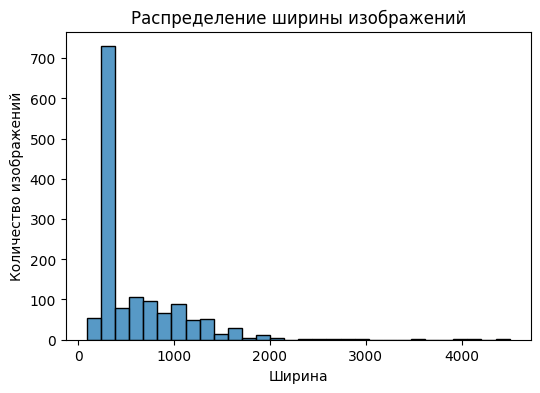

In [35]:
plt.figure(figsize=(6, 4))
sns.histplot(image_size_data['width'], bins=30)
plt.title('Распределение ширины изображений')
plt.xlabel('Ширина')
plt.ylabel('Количество изображений')
plt.show()

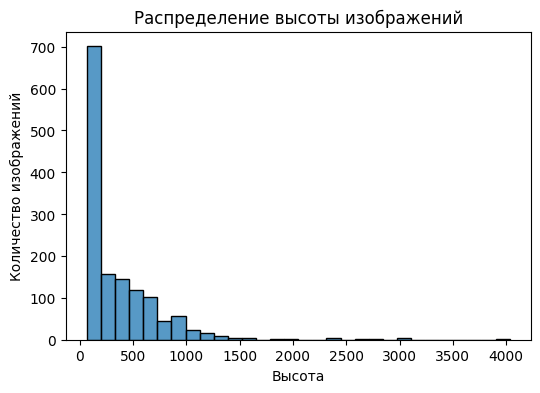

In [36]:
plt.figure(figsize=(6, 4))
sns.histplot(image_size_data['height'], bins=30)
plt.title('Распределение высоты изображений')
plt.xlabel('Высота')
plt.ylabel('Количество изображений')
plt.show()

Размеры файлов сильно различаются. Большая часть изображений имеет относительно небольшой размер, но также присутствуют изображения с очень большой шириной или высотой. Перед обучением CNN изображения нам необходимо привести к единому размеру

Также проверим, можно ли открыть каждое изображение из обучающей выборки

In [37]:
broken_images = []
for path in image_data['full_image_path']:
    try:
        try_image = plt.imread(path)
    except Exception as error:
        broken_images.append((path, error))

In [38]:
len(broken_images)

0

Все файлы из обучающей выборки корректно открываются. Битых нет

### Разбиение данных

Перед обучением моделей разделим данные на три части:

- `train` - используется для обучения модели
- `validation` - используется для выбора гиперпараметров и контроля переобучения
- `test` - используется только для финальной оценки качества модели

Т.к. распределение целевой переменной `Condition` сильно несбалансировано, разбиение нужно выполнять со стратификацией. Т.е. доли классов `0` и `1` будут примерно одинаковыми в train, validation и test

In [39]:
train_val_data, test_image_data = train_test_split(image_data, test_size=0.15, random_state=random_state, stratify=image_data['Condition'])

In [40]:
train_image_data, val_image_data = train_test_split(train_val_data, test_size=0.15, random_state=random_state, stratify=train_val_data['Condition'])

15% данных откладываем для финального тестирования. При 1399 объектах это около 210 изображений

In [41]:
len(train_image_data)

1010

In [42]:
len(val_image_data)

179

In [43]:
len(test_image_data)

210

### Преобразование изображений

Перед обучением CNN изображения необходимо привести к единому формату.

По результатам нпшего анализа все изображения обучающей выборки имеют 3 канала, то есть являются RGB-изображениями. При этом размеры изображений различаются, поэтому перед подачей в модель их нужно привести к одинаковой высоте и ширине. В PyTorch после преобразования `ToTensor()` изображение подается в модель в формате `C на H на W`.

Для обучающей выборки дополнительно используются аугментации

В нашем случае используем только умеренные аугментации, которые реалистичны для фотографий автомобилей:

- горизонтальное отражение
- небольшой поворот

Для validation и test случайные аугментации не применяются, потому что эти выборки используются для стабильной оценки качества модели

In [44]:
train_transforms = transforms.Compose([transforms.ToPILImage(), transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(p=0.5), transforms.RandomRotation(degrees=10), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

https://docs.pytorch.org/vision/0.9/transforms.html

https://deepmachinelearning.ru/docs/Neural-networks/Regularization/Augmentation

https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html

Для train используются следующие преобразования:

- `ToPILImage()` = переводит изображение в формат, совместимый с `torchvision.transforms`
- `Resize((224, 224))` - приводит все изображения к единому размеру
- `RandomHorizontalFlip(p=0.5)` - отражает часть изображений по горизонтали, что хорошо для фотографий автомобилей с разных сторон. Т.е. каждое изображение отражается по горизонтали с вероятностью 50%
- `RandomRotation(degrees=10)` - добавляет небольшой поворот, имитируя реальные фотографии, сделанные не строго ровно
- `ToTensor()` - переводит изображение в PyTorch тензор формата
- `Normalize(...)` - нормализует RGB каналы для совместимости с предварительно обученными моделями

Более агрессивные аугментации не используются, потому что они могут исказить признаки повреждений, например царапины, вмятины и деформации кузова

Размер `224 на 224` выбран, т.к. он позволяет формировать батчи одинаковой формы и совместим с типовой предобработкой для предварительно обученных CNN архитектур из torchvision, где например для ResNet используется итоговый размер `224 на 224`

Остальные значения также используются для совместимости с моделями. Такие значения указаны в предоработке для моделей, обученных на ImageNet. Эту же нормализацию применяем ко всем архитектурам, чтобы сравнение моделей было корректным

In [45]:
eval_transforms = transforms.Compose([transforms.ToPILImage(), transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

Для validation и test используются только детерминированные преобразования: `ToPILImage`, `Resize`, `ToTensor`, `Normalize`
Случайные преобразования здесь не применяются, чтобы метрики качества не зависели от случайности аугментаций

Проверим работу train_transforms на одном изображении

In [46]:
sample_image_path = image_data.loc[0, 'full_image_path']
sample_image = plt.imread(sample_image_path)

In [47]:
transformed_image = train_transforms(sample_image)

In [48]:
sample_image.shape

(418, 630, 3)

In [49]:
transformed_image.shape

torch.Size([3, 224, 224])

In [50]:
type(transformed_image)

torch.Tensor

сработало

In [51]:
transformed_image.min()

tensor(-2.1179)

In [52]:
transformed_image.max()

tensor(2.6400)

In [53]:
transformed_image.mean()

tensor(0.0450)

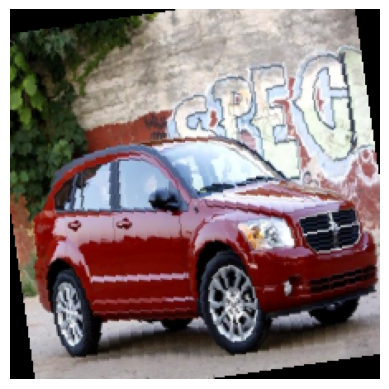

In [54]:
image_to_show = transformed_image.permute(1, 2, 0)
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])
image_to_show = image_to_show*std+mean
image_to_show = image_to_show.clamp(0, 1)
plt.imshow(image_to_show)
plt.axis('off')
plt.show()

### Создание собственного Dataset

В нашем датасете изображения и разметка хранятся отдельно, т.е. имена файлов находятся в столбце `Image_path`, целевая переменная в столбце `Condition`, а сами изображения лежат в папке `trainImages`.

Поэтому для обучения в PyTorch создаем собственный класс `Dataset`, который по индексу будет:

1. брать строку из таблицы
2. строить путь к изображению
3. считывать изображение
4. применять transforms
5. возвращать пару `(image, label)`

После этого `Dataset` будет передаваться в `DataLoader`, который будет формировать батчи и позволяет перемешивать train выборку

Входновители:
- https://docs.pytorch.org/tutorials/beginner/data_loading_tutorial.html
- https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html
- https://habr.com/ru/articles/553716/
- https://www.learnpytorch.io/04_pytorch_custom_datasets/
- https://docs.pytorch.org/docs/2.12/data.html

In [55]:
class MyDataset(Dataset):
    def __init__(self, data, images_dir, transform=None):
        self.data = data.reset_index(drop=True)
        self.images_dir = images_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        row = self.data.iloc[index]
        image = plt.imread(self.images_dir / row['Image_path'])
        label = row['Condition']
        label = torch.tensor(label, dtype=torch.float32)
        if self.transform is not None:
            image = self.transform(image)
        return image, label

В данном классе

- `data` - таблица с Image_path и Condition
- `images_dir` - папка, где лежат изображения
- `transform` - набор преобразований для изображения
- `__len__` возвращает размер датасета
- `__getitem__` возвращает одно изображение и его метку

Метка переводится в `torch.float32`, потому что далее для бинарной классификации будет использоваться `BCEWithLogitsLoss`, который работает с вещественными таргетами `0.0` и `1.0`

Теперь создаем три датасета:

- `train_dataset` использует train выборку и преобразования с аугментациями
- `val_dataset` использует validation выборку и преобразования без случайных аугментаций
- `test_dataset` использует test выборку и преобразования без случайных аугментаций

In [56]:
train_dataset = MyDataset(data=train_image_data, images_dir=DATA_DIR / 'trainImages', transform=train_transforms)

In [57]:
val_dataset = MyDataset(data=val_image_data, images_dir=DATA_DIR / 'trainImages', transform=eval_transforms)

In [58]:
test_dataset = MyDataset(data=test_image_data, images_dir=DATA_DIR / 'trainImages', transform=eval_transforms)

Проверим один объект

In [59]:
image, label = train_dataset[0]

In [60]:
image.shape

torch.Size([3, 224, 224])

In [61]:
label

tensor(1.)

In [62]:
type(image), type(label)

(torch.Tensor, torch.Tensor)

### Создание DataLoader

После создания `Dataset` создадим `DataLoader`

`DataLoader` нужен для формирования батчей. Нейронная сеть обучается на небольших группах объектов.

Для обучающей выборки используем `shuffle=True`, чтобы порядок объектов перемешивался между эпохами. Для validation и test используем `shuffle=False`, так как эти выборки нужны только для оценки качества модели

Выбираем размер батча = 32, он обычно помещается в память при работе с изображениями `224 на 224` и позволяет обучать модель стабильнее, чем при очень маленьком батче

In [63]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [64]:
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [65]:
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Проверим один батч

In [66]:
batch_images, batch_labels = next(iter(train_loader))

In [67]:
batch_images.shape

torch.Size([32, 3, 224, 224])

In [68]:
batch_labels.shape

torch.Size([32])

### Настройка устройства для обучения

Перед обучением модели задаем устройство вычислений. Если доступна видеокарта, модель и батчи будут переноситься на cuda, иначе обучение будет выполняться на cpu

In [69]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

- https://docs.pytorch.org/docs/2.12/cuda.html
- https://docs.pytorch.org/docs/2.12/generated/torch.Tensor.to.html

### Модель 1. BaselineCNN

Первой архитектурой будет простая сверточная нейронная сеть, обучаемая с нуля. Она нужна как бейслайн нам. С ней будем сравнивать более сложные архитектуры Базовая CNN строится из последовательности блоков:

`Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d`

После сверточной части используется `AdaptiveAvgPool2d`, затем `Dropout` и финальный линейный слой с одним выходом. Один выход нужен потому, что задача бинарная и модель должна вернуть один logit для каждого изображения

- https://neerc.ifmo.ru/wiki/index.php?title=%D0%A1%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D1%8B%D0%B5_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5_%D1%81%D0%B5%D1%82%D0%B8
- https://habr.com/ru/articles/436838/
- https://habr.com/ru/companies/mvideo/articles/782360/
- https://education.yandex.ru/handbook/ml/article/svyortochnye-nejroseti

In [70]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.3),
            nn.Linear(128, 1)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x.squeeze(1)

Проверим, что архитектура в целом норм работает, принимает батч и возвращает выход нужной формы

In [71]:
model = BaselineCNN().to(device)

In [72]:
batch_images = batch_images.to(device)

In [73]:
with torch.no_grad():
    outputs = model(batch_images)

In [74]:
outputs.shape

torch.Size([32])

In [75]:
outputs[:5]

tensor([-0.5273, -0.9408, -0.8511, -0.0517, -0.8988])

Все ок. Для каждого изображения из батча модель вернула один logit

https://docs.pytorch.org/docs/2.12/generated/torch.nn.BCEWithLogitsLoss.html

https://docs.pytorch.org/docs/2.12/generated/torch.no_grad.html

Зададим функцию потерь и оптимизатор

In [76]:
criterion = nn.BCEWithLogitsLoss()

BCEWithLogitsLoss используется для бинарной классификации, когда модель возвращает один logit для каждого объекта. Эта функция внутри объединяет sigmoid и binary cross-entropy, поэтому отдельно добавлять sigmoid в модель не нужно

https://docs.pytorch.org/docs/2.12/generated/torch.nn.Sigmoid.html

In [77]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)

https://docs.pytorch.org/docs/2.12/optim.html

Напишем функцию обучения одной эпохи. Функция train_one_epoch выполняет один полный проход по обучающей выборке. Внутри нее модель переводится в режим обучения, считаются предсказания, loss, градиенты и обновляются веса. В конце функция возвращает среднее значение loss за эпоху

https://yassin01.medium.com/understanding-the-difference-between-model-eval-and-model-train-in-pytorch-48e3002ee0a2

In [78]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()*images.size(0)
    avg_loss = total_loss/len(dataloader.dataset)
    return avg_loss

Функция evaluate используется для оценки модели без обновления весов. Она переводит модель в режим eval, отключает расчет градиентов и считает loss, accuracy, precision, recall, F1-score и ROC-AUC. Модель возвращает logits, затем они переводятся в вероятности с помощью torch.sigmoid. После этого вероятности преобразуются в классы по порогу 0.5

In [79]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            probs = torch.sigmoid(outputs)
            total_loss += loss.item()*images.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    avg_loss = total_loss/len(dataloader.dataset)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_preds = (all_probs>=0.5).astype(int)
    metrics = {
        'loss': avg_loss,
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, zero_division=0),
        'recall': recall_score(all_labels, all_preds, zero_division=0),
        'f1': f1_score(all_labels, all_preds, zero_division=0),
        'roc_auc': roc_auc_score(all_labels, all_probs)
    }
    return metrics

#### Логирование экспериментов через mlflow и dagshub

Добавим логированин экспериментов. Будем сохранять результаты разных архитектур в едином формате, чтобы нам было дальше удобно сравнивать. Каждый запуск модели будем оформлять как отдельный mlflow run. В run будут логироваться:
- параметры эксперимента: архитектура, размер изображения, batch size, learning rate, optimizer, функция потерь, preprocessing
- метрики по эпохам: train loss, validation loss, accuracy, precision, recall, F1-score, ROC-AUC
- итоговые test метрики
- артефакты: графики обучения, classification report, confusion matrix, предсказания на test выборке и веса модели 

Для удаленного хранения экспериментов будем использовать DagsHub. Если DagsHub не будет работать, будем работать локально через SQLite

https://mlflow.org/docs/latest/self-hosting

https://habr.com/ru/companies/digdes/articles/673324

https://habr.com/ru/companies/ods/articles/828458

In [80]:
import mlflow
import time

/Users/edos/gp/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Настроем подключение к DagsHub, если он доступен

In [81]:
use_dagshub = True

In [82]:
if use_dagshub:
    try:
        import dagshub
        dagshub.init(repo_owner='RenataMal', repo_name='GP5', mlflow=True)
        tracking_mode = 'dagshub'
    except Exception as error:
        print('DagsHub недоступен, используем локальный MLflow')
        print(error)
        mlflow.set_tracking_uri('sqlite:///mlflow.db')
        tracking_mode = 'local'
else:
    mlflow.set_tracking_uri('sqlite:///mlflow.db')
    tracking_mode = 'local'

Accessing as Nika022

Initialized MLflow to track repo "RenataMal/GP5"

Repository RenataMal/GP5 initialized!

In [83]:
mlflow.get_artifact_uri()

2026/06/13 09:15:26 WARNING mlflow.tracking.fluent: No active run found. A new active run will be created. If this is not intended, please create a run using `mlflow.start_run()` first.


'mlflow-artifacts:/fbb6f5b0d3254b0f89524f9fdc27a812/fa8cf15e458c4d0497fb079fb077744f/artifacts'

In [84]:
mlflow.set_experiment('GP5_car_damage_classification')

<Experiment: artifact_location='mlflow-artifacts:/fbb6f5b0d3254b0f89524f9fdc27a812', creation_time=1781210520116, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1781210520116, lifecycle_stage='active', name='GP5_car_damage_classification', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

In [85]:
tracking_mode

'dagshub'

In [86]:
mlflow.set_tracking_uri('https://dagshub.com/RenataMal/GP5.mlflow')

In [87]:
mlflow.get_tracking_uri()

'https://dagshub.com/RenataMal/GP5.mlflow'

Теперь дальнейшие mlflow запуски будут отправляться в DagsHub репозиторий проекта, либо сохраняться локально через SQLite. После восстановления DagsHub можно будет переключить `use_dagshub = True` и отправлять эксперименты в удаленный репозиторий проекта

Зададим основные параметры эксперимента

https://mlflow.org/docs/latest/ml/tracking

https://mlflow.org/docs/latest/ml/tracking/tracking-api

https://mlflow.org/docs/latest/self-hosting/architecture/backend-store

In [88]:
num_epochs = 10
learning_rate = 1e-3
batch_size = 32
image_size = 224

Также ниже мы будем строить различные артефакты. СоздадИм функцию для построения и сохранения графиков обучения. Она сохраняет два графика: динамику функции потерь и динамику метрик валидации

In [89]:
def save_training_plots(history_data, model_name):
    loss_plot_path = f'{model_name}_loss_plot.png'
    plt.figure(figsize=(6, 4))
    plt.plot(history_data['epoch'], history_data['train_loss'], label='Ошибка на обучении')
    plt.plot(history_data['epoch'], history_data['val_loss'], label='Ошибка на валидации')
    plt.xlabel('Эпоха')
    plt.ylabel('Значение функции потерь')
    plt.title(f'{model_name}: ошибка на обучении и валидации')
    plt.legend()
    plt.savefig(loss_plot_path, bbox_inches='tight')
    plt.show()
    metrics_plot_path = f'{model_name}_metrics_plot.png'
    plt.figure(figsize=(9, 4))
    plt.plot(history_data['epoch'], history_data['val_f1'], label='F1-score на валидации')
    plt.plot(history_data['epoch'], history_data['val_roc_auc'], label='ROC-AUC на валидации')
    plt.xlabel('Эпоха')
    plt.ylabel('Значение метрики')
    plt.title(f'{model_name}: метрики качества на валидации')
    plt.legend()
    plt.savefig(metrics_plot_path, bbox_inches='tight')
    plt.show()
    return loss_plot_path, metrics_plot_path

Также создадим функцию для построения и сохранения матрицы ошибок

In [90]:
def save_confusion_matrix_plot(y_true, y_pred, model_name):
    conf_matrix = confusion_matrix(y_true, y_pred)
    conf_matrix_path = f'{model_name}_confusion_matrix.png'
    plt.figure(figsize=(5, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='PuRd', xticklabels=['Без повреждений', 'С повреждениями'], yticklabels=['Без повреждений', 'С повреждениями'])
    plt.xlabel('Предсказанный класс')
    plt.ylabel('Истинный класс')
    plt.title(f'{model_name}: матрица ошибок')
    plt.savefig(conf_matrix_path, bbox_inches='tight')
    plt.show()
    return conf_matrix_path

Конечно еще создадим функцию для сохранения classification report. Этот отчет показывает precision, recall и F1-score отдельно для каждого класса

In [91]:
def save_classification_report(y_true, y_pred, model_name):
    report_text = classification_report(y_true, y_pred, target_names=['Без повреждений', 'С повреждениями'], zero_division=0)
    report_path = f'{model_name}_classification_report.txt'
    with open(report_path, 'w', encoding='utf-8') as file:
        file.write(report_text)
    print(report_text)
    return report_path

Чтобы было видно качество по каждому классу, напишем отдельную функцию get_predictions. Модель переводится в режим оценки, затем для каждого батча считаются logits, вероятности через sigmoid и итоговые классы по порогу 0.5

In [92]:
def get_predictions(model, dataloader, device):
    model.eval()
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_preds = (all_probs>=0.5).astype(int)
    return all_labels, all_preds, all_probs

Создадим единую функцию run_cv_experiment. Она будет выполнять полный пайплайн обучения для одной модели. Внутри функции будут выполняться основные этапы эксперимента: обучение модели по эпохам, оценка на validation, расчет test метрик, сохранение истории обучения, графиков, classification report, confusion matrix, предсказаний и весов модели. Каждая модель будет опять же логироваться как отдельный mLflow run

https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html

https://docs.pytorch.org/tutorials/beginner/basics/saveloadrun_tutorial.html

In [93]:
def run_cv_experiment(model_name, model, train_loader, val_loader, test_loader, criterion, optimizer, device, num_epochs,params):
    model = model.to(device)
    history = []
    with mlflow.start_run(run_name=model_name):
        mlflow.log_params(params)
        start_training_time = time.time()
        for epoch in range(num_epochs):
            start_epoch_time = time.time()
            train_loss = train_one_epoch(model=model, dataloader=train_loader, criterion=criterion, optimizer=optimizer, device=device)
            val_metrics = evaluate(model=model, dataloader=val_loader, criterion=criterion, device=device)
            epoch_time = time.time()-start_epoch_time
            epoch_result = {'epoch': epoch+1,
                'train_loss': train_loss,
                'val_loss': val_metrics['loss'],
                'val_accuracy': val_metrics['accuracy'],
                'val_precision': val_metrics['precision'],
                'val_recall': val_metrics['recall'],
                'val_f1': val_metrics['f1'],
                'val_roc_auc': val_metrics['roc_auc'],
                'epoch_time_sec': epoch_time}
            history.append(epoch_result)
            mlflow.log_metric('train_loss', train_loss, step=epoch+1)
            mlflow.log_metric('val_loss', val_metrics['loss'], step=epoch+1)
            mlflow.log_metric('val_accuracy', val_metrics['accuracy'], step=epoch+1)
            mlflow.log_metric('val_precision', val_metrics['precision'], step=epoch+1)
            mlflow.log_metric('val_recall', val_metrics['recall'], step=epoch+1)
            mlflow.log_metric('val_f1', val_metrics['f1'], step=epoch+1)
            mlflow.log_metric('val_roc_auc', val_metrics['roc_auc'], step=epoch+1)
            mlflow.log_metric('epoch_time_sec', epoch_time, step=epoch+1)
            print(f"Эпоха {epoch + 1}/{num_epochs} | ошибка на обучении: {train_loss:.4f} | ошибка на валидации: {val_metrics['loss']:.4f} | accuracy: {val_metrics['accuracy']:.4f} | F1: {val_metrics['f1']:.4f} | ROC-AUC: {val_metrics['roc_auc']:.4f} | время эпохи: {epoch_time:.1f} сек")
        total_training_time = time.time()-start_training_time
        mlflow.log_metric('total_training_time_sec', total_training_time)
        history_data = pd.DataFrame(history)
        history_path = f'{model_name}_history.csv'
        history_data.to_csv(history_path, index=False)
        mlflow.log_artifact(history_path)
        loss_plot_path, metrics_plot_path = save_training_plots(history_data=history_data, model_name=model_name)
        mlflow.log_artifact(loss_plot_path)
        mlflow.log_artifact(metrics_plot_path)
        test_metrics = evaluate(model=model, dataloader=test_loader, criterion=criterion, device=device)
        mlflow.log_metric('test_loss', test_metrics['loss'])
        mlflow.log_metric('test_accuracy', test_metrics['accuracy'])
        mlflow.log_metric('test_precision', test_metrics['precision'])
        mlflow.log_metric('test_recall', test_metrics['recall'])
        mlflow.log_metric('test_f1', test_metrics['f1'])
        mlflow.log_metric('test_roc_auc', test_metrics['roc_auc'])
        test_labels, test_preds, test_probs = get_predictions(model=model, dataloader=test_loader, device=device)
        predictions_data = pd.DataFrame({'true_label': test_labels, 'predicted_label': test_preds, 'predicted_probability': test_probs})
        predictions_path = f'{model_name}_test_predictions.csv'
        predictions_data.to_csv(predictions_path, index=False)
        mlflow.log_artifact(predictions_path)
        report_path = save_classification_report(y_true=test_labels, y_pred=test_preds, model_name=model_name)
        mlflow.log_artifact(report_path)
        conf_matrix_path = save_confusion_matrix_plot(y_true=test_labels, y_pred=test_preds, model_name=model_name)
        mlflow.log_artifact(conf_matrix_path)
        model_weights_path = f'{model_name}.pt'
        torch.save(model.state_dict(), model_weights_path)
        mlflow.log_artifact(model_weights_path)
    return model, history_data, test_metrics

Сохраним и зафиксируем все параметры наши

In [94]:
baseline_params = {'model_name': 'BaselineCNN',
    'architecture': 'custom_cnn',
    'image_size': image_size,
    'batch_size': batch_size,
    'num_epochs': num_epochs,
    'learning_rate': learning_rate,
    'optimizer': 'Adam',
    'loss_function': 'BCEWithLogitsLoss',
    'use_pretrained': False,
    'train_size': len(train_dataset),
    'val_size': len(val_dataset),
    'test_size': len(test_dataset),
    'random_state': random_state,
    'resize': '224x224',
    'normalization_mean': '[0.485, 0.456, 0.406]',
    'normalization_std': '[0.229, 0.224, 0.225]',
    'train_augmentation': 'RandomHorizontalFlip(p=0.5), RandomRotation(degrees=10)',
    'eval_augmentation': 'None',
    'tracking_mode': tracking_mode}

#### Запуск BaselineCNN через наш пайплайн

Здесь как раз проведем наше основное обучение

In [136]:
baseline_model = BaselineCNN()

In [134]:
baseline_criterion = nn.BCEWithLogitsLoss()

In [137]:
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=learning_rate)

Эпоха 1/10 | ошибка на обучении: 0.2368 | ошибка на валидации: 0.2413 | accuracy: 0.9274 | F1: 0.9623 | ROC-AUC: 0.6775 | время эпохи: 21.2 сек
Эпоха 2/10 | ошибка на обучении: 0.2464 | ошибка на валидации: 0.2378 | accuracy: 0.9274 | F1: 0.9623 | ROC-AUC: 0.7118 | время эпохи: 20.9 сек
Эпоха 3/10 | ошибка на обучении: 0.2425 | ошибка на валидации: 0.2380 | accuracy: 0.9274 | F1: 0.9623 | ROC-AUC: 0.7298 | время эпохи: 21.1 сек
Эпоха 4/10 | ошибка на обучении: 0.2132 | ошибка на валидации: 0.2720 | accuracy: 0.9274 | F1: 0.9623 | ROC-AUC: 0.6997 | время эпохи: 21.1 сек
Эпоха 5/10 | ошибка на обучении: 0.2113 | ошибка на валидации: 0.2743 | accuracy: 0.9218 | F1: 0.9591 | ROC-AUC: 0.6881 | время эпохи: 20.6 сек
Эпоха 6/10 | ошибка на обучении: 0.2647 | ошибка на валидации: 0.2435 | accuracy: 0.9274 | F1: 0.9623 | ROC-AUC: 0.7104 | время эпохи: 21.0 сек
Эпоха 7/10 | ошибка на обучении: 0.2305 | ошибка на валидации: 0.2575 | accuracy: 0.9274 | F1: 0.9623 | ROC-AUC: 0.6622 | время эпохи: 2

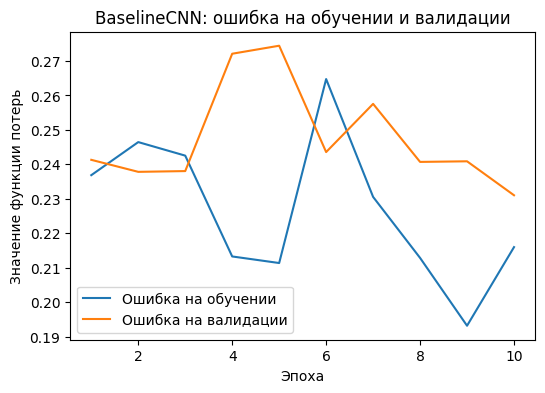

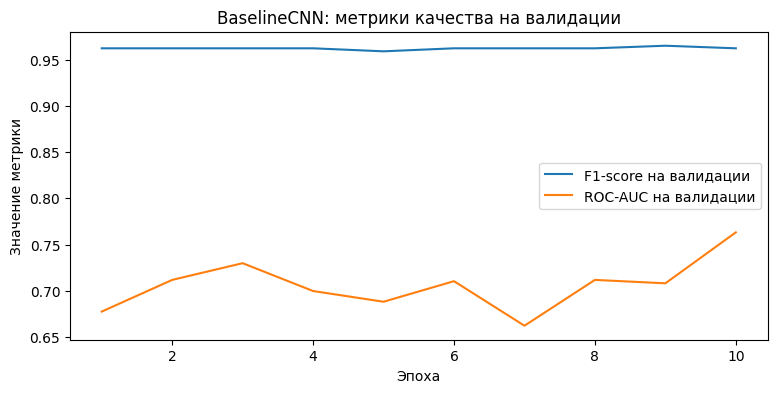

                 precision    recall  f1-score   support

Без повреждений       0.00      0.00      0.00        15
С повреждениями       0.93      1.00      0.96       195

       accuracy                           0.93       210
      macro avg       0.46      0.50      0.48       210
   weighted avg       0.86      0.93      0.89       210



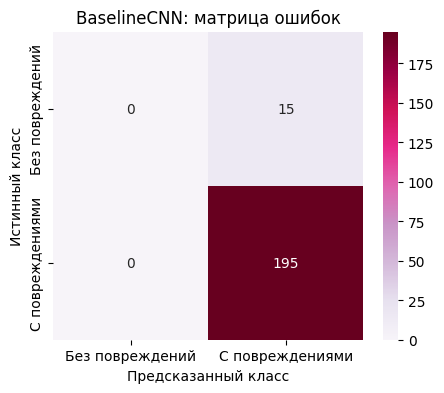

🏃 View run BaselineCNN at: https://dagshub.com/RenataMal/GP5.mlflow/#/experiments/0/runs/88b8061944564ee192d76a16d4d261a7
🧪 View experiment at: https://dagshub.com/RenataMal/GP5.mlflow/#/experiments/0


In [585]:
baseline_model, baseline_history_data, baseline_test_metrics = run_cv_experiment(model_name='BaselineCNN', model=baseline_model, train_loader=train_loader, val_loader=val_loader, test_loader=test_loader, criterion=baseline_criterion, optimizer=baseline_optimizer, device=device, num_epochs=num_epochs, params=baseline_params)

#### Результаты BaselineCNN

Выведим историю обучения модели

In [501]:
baseline_history_data

,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,epoch_time_sec
0,1,0.241156,0.252866,0.927374,0.927374,1.0,0.962319,0.686747,23.095872
1,2,0.227896,0.320619,0.927374,0.927374,1.0,0.962319,0.645505,22.092440
2,3,0.226349,0.308051,0.927374,0.927374,1.0,0.962319,0.565338,21.681795
3,4,0.242359,0.247502,0.927374,0.927374,1.0,0.962319,0.702039,22.698647
4,5,0.250899,0.251227,0.927374,0.927374,1.0,0.962319,0.695088,22.295028
5,6,0.249465,0.266353,0.927374,0.927374,1.0,0.962319,0.622799,22.265284
6,7,0.281251,0.254989,0.927374,0.927374,1.0,0.962319,0.664041,22.250553
7,8,0.218150,0.242420,0.927374,0.927374,1.0,0.962319,0.729379,22.211153
8,9,0.265775,0.265410,0.927374,0.927374,1.0,0.962319,0.597312,21.457677
9,10,0.231021,0.263807,0.927374,0.927374,1.0,0.962319,0.635774,21.922330


In [502]:
baseline_test_metrics_data = pd.DataFrame([baseline_test_metrics])
baseline_test_metrics_data

,loss,accuracy,precision,recall,f1,roc_auc
0,0.263129,0.928571,0.928571,1.0,0.962963,0.617436


Сохраним результаты в словарик

In [503]:
baseline_results = {'model': 'BaselineCNN', 'test_loss': baseline_test_metrics['loss'], 
    'test_accuracy': baseline_test_metrics['accuracy'], 'test_precision': baseline_test_metrics['precision'],
    'test_recall': baseline_test_metrics['recall'], 'test_f1': baseline_test_metrics['f1'], 'test_roc_auc': baseline_test_metrics['roc_auc']}
baseline_results

{'model': 'BaselineCNN',
 'test_loss': 0.2631293785004389,
 'test_accuracy': 0.9285714285714286,
 'test_precision': 0.9285714285714286,
 'test_recall': 1.0,
 'test_f1': 0.9629629629629629,
 'test_roc_auc': 0.6174358974358973}

BaselineCNN была использована как первая базовая архитектура, обучаемая с нуля. Она будет епе точка отсчета для сравнения с более сложными CNN моделями. Модель была обучена через общий пайплайн обученич, а параметры, метрики и артефакты эксперимента были сохранены в mlflow.

На test выборке модель показала высокую accuracy около 0.93, а также высокий F1-score для класса "С повреждениями". Однако эти значения нельзя интерпретировать как полноценный успех модели, потому что в данных есть сильный дисбаланс классов, большая часть изображений относится к классу `Condition = 1`.

Classification report показывает, что BaselineCNN фактически не распознает класс "Без повреждений". precision, recall и F1-score для этого класса равны 0. Модель почти всегда выбирает мажоритарный класс "С повреждениями". Поэтому высокая accuracy в данном случае отражает перекос распределения классов.

ROC-AUC на test выборке находится примерно на уровне 0.63. Модель частично научилась ранжировать изображения по вероятности класса `1`, но ее разделяющая способность пока ограничена. Confusion matrix дополнительно подтверждает, основной проблемоц модели является слабая работа с редким классом `Condition = 0`.

BaselineCNN можно считать корректной стартовой моделью, она обучается, loss снижается, пайплайн работает, метрики и артефакты логируются. Но по качеству эта архитектура недостаточна для практического применения. В следующих экспериментах нужно проверить более сильные архитектуры

### Визуализация фильтров и карт признаков BaselineCNN

После обучения BaselineCNN дополнительно визуализируем, что происходит внутри сверточной сети.Сначала посмотрим на фильтры первого сверточного слоя. В сверточной сети фильтр является набором обучаемых весов, которые применяются к изображению и помогают выделять локальные паттерны. Затем визуализируем карты признаков для одного изображения. Карта признаков показывает, как конкретный фильтр реагирует на разные области входного изображения

https://docs.pytorch.org/docs/2.12/generated/torch.nn.Conv2d.html

У нас первый сверточный слой находится здесь

In [154]:
baseline_model.features[0]

Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

Извлечем веса первого слоя

In [155]:
filters = baseline_model.features[0].weight.data.cpu()

In [116]:
filters.shape

torch.Size([32, 3, 3, 3])

Визуализируем первые 16 фильтров. Напишем функцию для этого. Посмотрим какие низкоуровневые цветовые и локальные паттерны выучила модель в первом сверточном слое

In [505]:
def show_first_layer_filters(model, n_filters=16):
    first_conv_layer = model.features[0]
    filters = first_conv_layer.weight.data.cpu()
    n_filters = min(n_filters, filters.shape[0])
    plt.figure(figsize=(10, 10))
    for i in range(n_filters):
        filter_img = filters[i]
        filter_img = filter_img.permute(1, 2, 0)
        filter_img = filter_img-filter_img.min()
        filter_img = filter_img/filter_img.max()
        plt.subplot(4, 4, i+1)
        plt.imshow(filter_img)
        plt.title(f'Фильтр {i + 1}')
        plt.axis('off')
    plt.suptitle('Фильтры первого сверточного слоя BaselineCNN')
    plt.tight_layout()
    plt.show()

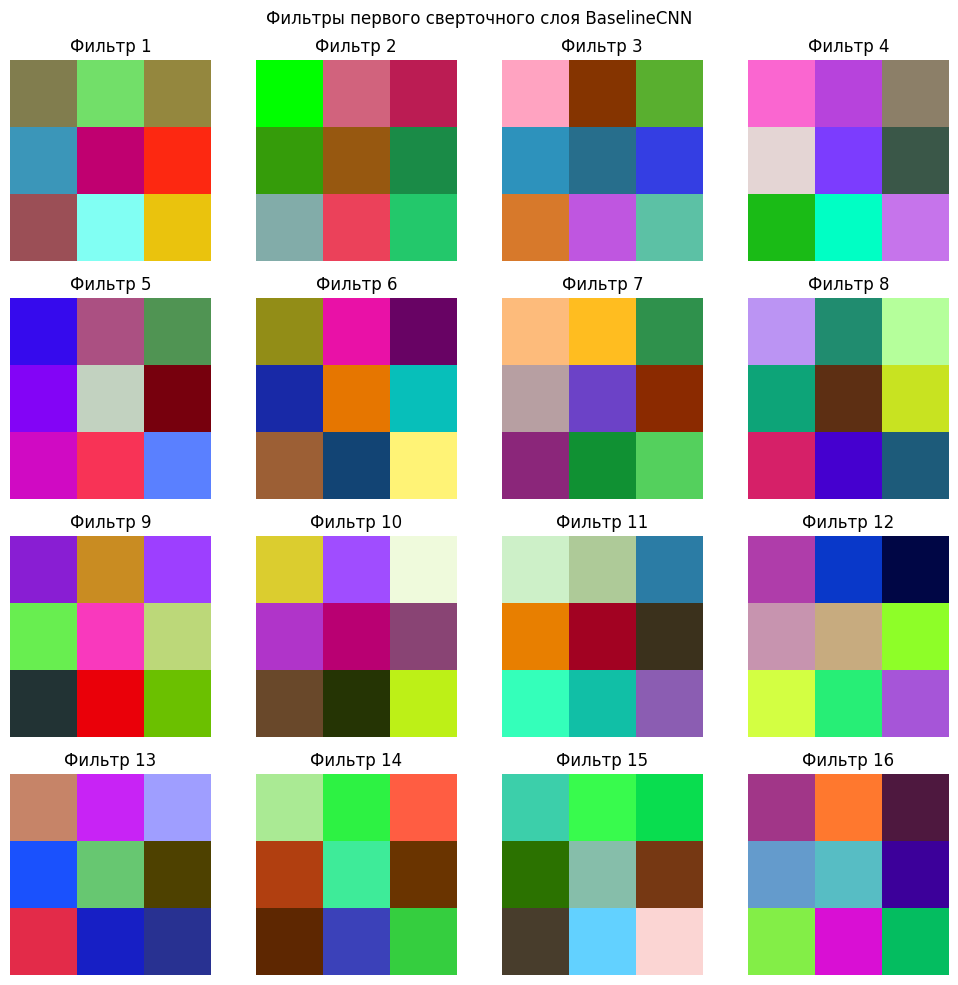

In [506]:
show_first_layer_filters(baseline_model, n_filters=16)

Теперь возьмем одно изображение из `test_dataset`

In [507]:
sample_image, sample_label = test_dataset[0]

In [508]:
sample_image_batch = sample_image.unsqueeze(0).to(device)

In [509]:
sample_image_batch.shape

torch.Size([1, 3, 224, 224])

In [510]:
sample_label

tensor(0.)

In [511]:
baseline_model.eval()
with torch.no_grad():
    first_block_features = baseline_model.features[:4](sample_image_batch)

In [512]:
first_block_features.shape

torch.Size([1, 32, 112, 112])

То есть получили 32 карты признаков после первого блока. Каждая карта показывает, как один фильтр реагирует на разные области изображения

Теперь визуализируем первые 16 карт признаков. Напишем также для этого функцию. Карты признаков показываются в оттенках серого. Более светлые участки соответствуют более сильным активациям, т.е. тем областям изображения, где фильтр нашел свой паттерн

In [513]:
def show_feature_maps(feature_maps, n_maps=16):
    feature_maps = feature_maps.squeeze(0).cpu()
    n_maps = min(n_maps, feature_maps.shape[0])
    plt.figure(figsize=(10, 10))
    for i in range(n_maps):
        feature_map = feature_maps[i]
        plt.subplot(4, 4, i+1)
        plt.imshow(feature_map, cmap='gray')
        plt.title(f'Карта {i+1}')
        plt.axis('off')
    plt.suptitle('Карты признаков после первого сверточного блока')
    plt.tight_layout()
    plt.show()

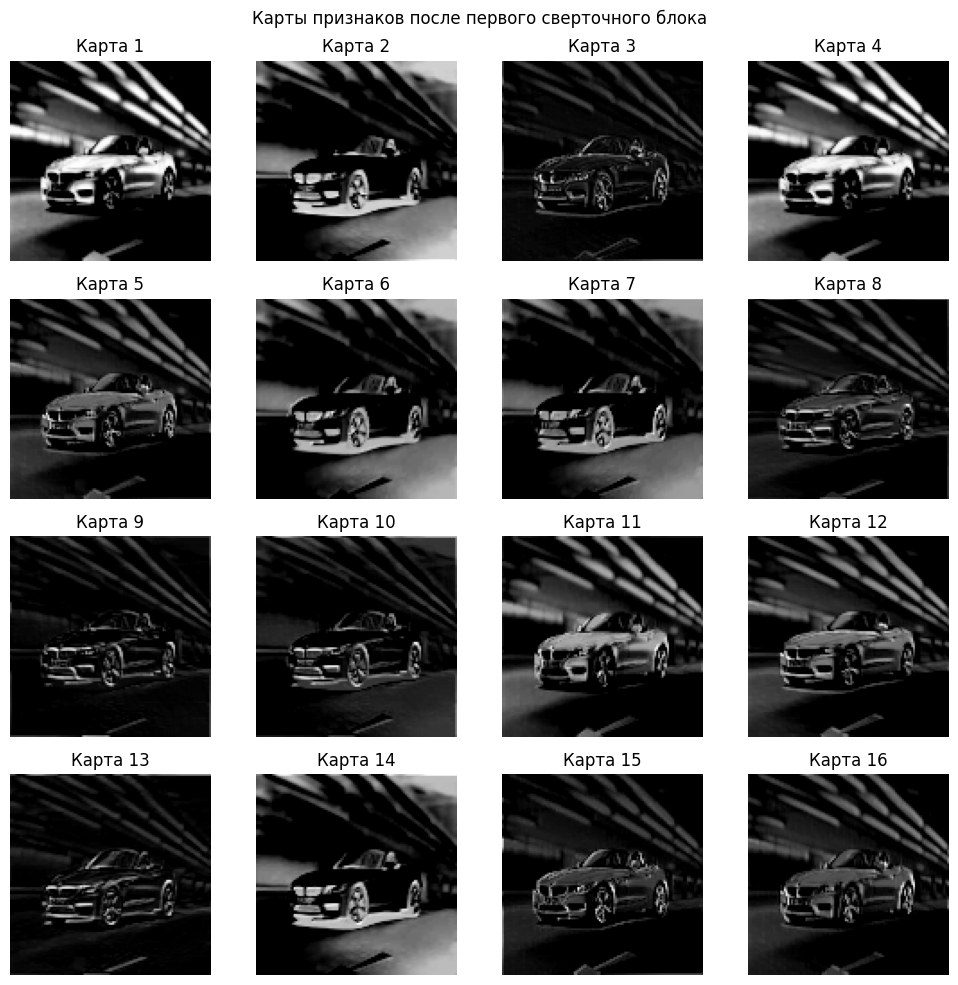

In [514]:
show_feature_maps(first_block_features, n_maps=16)

Напишем функцию для отображения исходного изображения после обратной нормализации

In [517]:
def show_denormalized_image(image_tensor):
    image = image_tensor.cpu().permute(1, 2, 0)
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    image = image*std+mean
    image = image.clamp(0, 1)
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title('Исходное изображение после обратной нормализации')
    plt.axis('off')
    plt.show()

Покажем исходное изображение, для которого строили карты признаков

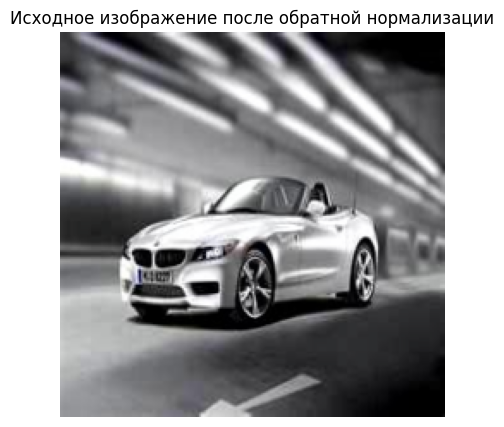

In [518]:
show_denormalized_image(sample_image)

# ConvNeXT

Поставим timm для скачивания образов моделей с HF

In [145]:
%pip install timm

Note: you may need to restart the kernel to use updated packages.


In [146]:
import timm

In [147]:
model_name_convnext = 'convnext_atto' 
model_convnext = timm.create_model(model_name_convnext, pretrained=True, num_classes=1)
model_convnext = model_convnext.to(device)

In [148]:
weight_clean = sum(item[1] for item in train_dataset) / len(train_dataset)
weight_damage = 1 - weight_clean
class_weights = torch.tensor([weight_clean, weight_damage], dtype=torch.float).to(device)

In [149]:
class_weights

tensor([0.9297, 0.0703])

Видим, что дисбаланс очень большой - он не то, чтобы стандартный - как например, 70/30, 80/20, а еще сильнее

Попробуем решить эту проблему с помощью WeightedRandomSampler из torch.utils

In [150]:
from torch.utils.data import WeightedRandomSampler

In [151]:
class_weight_clean = 1.0 / weight_clean
class_weight_damage = 1.0 / weight_damage

sample_weights = [class_weight_clean if label[1] == 1 else class_weight_damage for label in train_dataset]

sampler = WeightedRandomSampler(
    weights=sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True
)

sampler.weights

tensor([1.0756, 1.0756, 1.0756,  ..., 1.0756, 1.0756, 1.0756],
       dtype=torch.float64)

In [152]:
unique_weights = torch.unique(sampler.weights)
print("Уникальные веса в сэмплере:", unique_weights)

for weight in unique_weights:
    count = (sampler.weights == weight).sum().item()
    print(f"Вес {weight.item():.6f} назначен для {count} изображений.")

Уникальные веса в сэмплере: tensor([ 1.0756, 14.2254], dtype=torch.float64)
Вес 1.075612 назначен для 939 изображений.
Вес 14.225358 назначен для 71 изображений.


In [153]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size,
    sampler=sampler,
    num_workers=0,
    pin_memory=False
)

In [154]:
convnext_params = {
    'model_name': 'ConvNeXt_Atto_Final',
    'architecture': 'convnext_atto',
    'image_size': image_size,
    'batch_size': batch_size,
    'num_epochs_stage1': 2,                  
    'epochs': 6, # лучше всего колво эпох делать так, тк отдельным параметром
    'learning_rate_stage1': 1e-3,
    'learning_rate_stage2': 1e-5, # для ускорения обучения,  мб потом можно поставить 1e-5
    'optimizer_stage1': 'AdamW', # оптимизатор до разморозки
    'optimizer_stage2': 'AdamW', # после 
    'loss_function': 'BCEWithLogitsLoss_Weighted',
    'use_pretrained': True,                  
    'train_size': len(train_dataset),
    'val_size': len(val_dataset),
    'test_size': len(test_dataset),
    'random_state': random_state,
    'resize': '224x224',
    'normalization_mean': '[0.485, 0.456, 0.406]', 
    'normalization_std': '[0.229, 0.224, 0.225]',
    'train_augmentation': 'RandomHorizontalFlip(p=0.5), RandomRotation(degrees=10), ColorJitter',
    'eval_augmentation': 'None',
    'tracking_mode': tracking_mode
}

In [155]:
class EarlyStopping:
    def __init__(self, waiting=3, verbose=True, path='best_model.pth'):
        """
        waiting (int): Сколько эпох ждать улучшения перед остановкой
        verbose (bool): Выводить ли сообщения о сохранении модели
        path (str): Путь для сохранения весов лучшей модели
        """
        self.waiting = waiting
        self.verbose = verbose
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
        elif val_loss >= self.best_loss:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.waiting}')
            if self.counter >= self.waiting:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased to {val_loss}. Saving model to {self.path}...')
        torch.save(model.state_dict(), self.path)


In [156]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)

            labels = labels.unsqueeze(1) # выравнивание тензоров, тк в кастомной модели это уже вроде есть

            loss = criterion(outputs, labels)
                
            probs = torch.sigmoid(outputs)
            total_loss += loss.item()*images.size(0)
            all_labels.extend(labels.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())
        avg_loss = total_loss/len(dataloader.dataset)
        all_labels = np.array(all_labels)
        all_probs = np.array(all_probs)
        all_preds = (all_probs>=0.5).astype(int)
        metrics = {
            'loss': avg_loss,
            'accuracy': accuracy_score(all_labels, all_preds),
            'precision': precision_score(all_labels, all_preds, zero_division=0),
            'recall': recall_score(all_labels, all_preds, zero_division=0),
            'f1': f1_score(all_labels, all_preds, zero_division=0),
            'roc_auc': roc_auc_score(all_labels, all_probs)
        }
    return metrics

тут можно было бы оптимизировать шаг обучения с помощью torch.GradeScaler
https://docs.pytorch.org/docs/2.12/amp.html

тк библиотека выбрала бы подходящий тип данных для хранения данных и классификации
но модель обучалась на CPU

In [157]:
def train_one_epoch_v2(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()

        labels = labels.unsqueeze(1) # то же самое

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()*images.size(0)
    avg_loss = total_loss/len(dataloader.dataset)
    return avg_loss

Создаем класс для сохранения лучшей модели и ее параметров
путь и сколько эпох ждать для улучшения результата (waiting)

In [158]:
model_path = 'model.pth'
early_stopping = EarlyStopping(waiting=7, verbose=True, path=model_path)

In [159]:
import copy

def run_cv_experiment_with_freeze(model_name, model, train_loader, val_loader, test_loader, criterion, optimizer, device,params,num_epochs=5):
    model = model.to(device)
    history = []

    epochs_s1 = params['num_epochs_stage1']
    num_epochs = params['epochs']

    # добавляем поиск лучшего val_loss
    best_val_loss = float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())

    with mlflow.start_run(run_name=model_name):
        mlflow.log_params(params)
        
        start_training_time = time.time()

        for param in model.parameters():
            param.requires_grad = False
        for param in model.head.parameters():
            param.requires_grad = True
            
        # фильтруем замороженные параметры модели под первый этап
        # чтобы Pytorch не выкидывал ошибки либо не использовал их лишний раз в памяти
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()), 
            lr=params['learning_rate_stage1']
        )
        
        for epoch in range(num_epochs):
            start_epoch_time = time.time()
            if epoch == epochs_s1:
                # эпока разморозки
                mlflow.set_tag("training_stage", "stage2_fine_tuning")
                
                for param in model.parameters():
                    param.requires_grad = True
                
                # возвращаем обратно все параметры
                optimizer = torch.optim.AdamW(
                    model.parameters(), 
                    lr=params['learning_rate_stage2'], 
                    weight_decay=1e-5
                )
            
            train_loss = train_one_epoch_v2(model=model, dataloader=train_loader, criterion=criterion, optimizer=optimizer, device=device)
            val_metrics = evaluate(model=model, dataloader=val_loader, criterion=criterion, device=device)
            epoch_time = time.time()-start_epoch_time
            epoch_result = {'epoch': epoch+1,
                'train_loss': train_loss,
                'val_loss': val_metrics['loss'],
                'val_accuracy': val_metrics['accuracy'],
                'val_precision': val_metrics['precision'],
                'val_recall': val_metrics['recall'],
                'val_f1': val_metrics['f1'],
                'val_roc_auc': val_metrics['roc_auc'],
                'epoch_time_sec': epoch_time}
            history.append(epoch_result)

            current_val_loss = val_metrics['loss']

            # достигнут лучший val_loss - сохраним модель
            if current_val_loss < best_val_loss:
                best_val_loss = current_val_loss
                best_epoch = epoch + 1
                # Сохраняем слепок лучших весов в оперативную память
                best_model_weights = copy.deepcopy(model.state_dict())
                mlflow.log_text(f"Достигнут новый минимум val_loss: {best_val_loss:.4f} на эпохе {best_epoch}!", artifact_file="./output.txt")

            # проверка val loss
            early_stopping(current_val_loss, model)
            if early_stopping.early_stop:
                mlflow.log_text("Ранняя остановка: Обучение прекращено, так как метрика на валидации перестала улучшаться.", artifact_file="./output.txt")
                break
            
            mlflow.log_metric('train_loss', train_loss, step=epoch+1)
            mlflow.log_metric('val_loss', val_metrics['loss'], step=epoch+1)
            mlflow.log_metric('val_accuracy', val_metrics['accuracy'], step=epoch+1)
            mlflow.log_metric('val_precision', val_metrics['precision'], step=epoch+1)
            mlflow.log_metric('val_recall', val_metrics['recall'], step=epoch+1)
            mlflow.log_metric('val_f1', val_metrics['f1'], step=epoch+1)
            mlflow.log_metric('val_roc_auc', val_metrics['roc_auc'], step=epoch+1)
            mlflow.log_metric('epoch_time_sec', epoch_time, step=epoch+1)
            
            print(f"Эпоха {epoch + 1}/{num_epochs} | ошибка на обучении: {train_loss:.4f} | ошибка на валидации: {val_metrics['loss']:.4f} | accuracy: {val_metrics['accuracy']:.4f} | F1: {val_metrics['f1']:.4f} | ROC-AUC: {val_metrics['roc_auc']:.4f} | время эпохи: {epoch_time:.1f} сек")
        
        total_training_time = time.time()-start_training_time
        mlflow.log_metric('total_training_time_sec', total_training_time)
        
        history_data = pd.DataFrame(history)
        history_path = f'{model_name}_history.csv'
        history_data.to_csv(history_path, index=False)

        # загружаем лучшую модель
        mlflow.log_text(f"Загружаем лучшие веса модели (с эпохи {best_epoch} с val_loss: {best_val_loss:.4f}) для финальной оценки...", artifact_file="./output.txt")
        model.load_state_dict(best_model_weights)
        
        mlflow.log_artifact(history_path)
        
        loss_plot_path, metrics_plot_path = save_training_plots(history_data=history_data, model_name=model_name)
        
        mlflow.log_artifact(loss_plot_path)
        mlflow.log_artifact(metrics_plot_path)
        
        test_metrics = evaluate(model=model, dataloader=test_loader, criterion=criterion, device=device)
        
        mlflow.log_metric('test_loss', test_metrics['loss'])
        mlflow.log_metric('test_accuracy', test_metrics['accuracy'])
        mlflow.log_metric('test_precision', test_metrics['precision'])
        mlflow.log_metric('test_recall', test_metrics['recall'])
        mlflow.log_metric('test_f1', test_metrics['f1'])
        mlflow.log_metric('test_roc_auc', test_metrics['roc_auc'])
        
        test_labels, test_preds, test_probs = get_predictions(model=model, dataloader=test_loader, device=device)
        
        predictions_data = pd.DataFrame({'true_label': test_labels, 'predicted_label': test_preds, 'predicted_probability': test_probs})
        predictions_path = f'{model_name}_test_predictions.csv'
        predictions_data.to_csv(predictions_path, index=False)
        
        mlflow.log_artifact(predictions_path)
        report_path = save_classification_report(y_true=test_labels, y_pred=test_preds, model_name=model_name)
        mlflow.log_artifact(report_path)
        conf_matrix_path = save_confusion_matrix_plot(y_true=test_labels, y_pred=test_preds, model_name=model_name)
        mlflow.log_artifact(conf_matrix_path)
        
        model_weights_path = f'{model_name}.pt'
        torch.save(best_model_weights, model_weights_path)
        
        mlflow.log_artifact(model_weights_path)
    return model, history_data, test_metrics

In [160]:
def get_predictions(model, dataloader, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            
            probs = torch.sigmoid(outputs)
            
            preds = (probs >= 0.5).int()

            all_labels.extend(labels.view(-1).cpu().tolist())
            all_preds.extend(preds.view(-1).cpu().tolist())
            all_probs.extend(probs.view(-1).cpu().tolist())
            
    return all_labels, all_preds, all_probs


In [161]:
convnext_optimizer = optim.Adam(model_convnext.parameters(), lr=learning_rate)

In [162]:
mlflow.end_run()

Validation loss decreased to 0.619101436444501. Saving model to model.pth...
Эпоха 1/6 | ошибка на обучении: 0.6045 | ошибка на валидации: 0.6191 | accuracy: 0.6369 | F1: 0.7619 | ROC-AUC: 0.8026 | время эпохи: 39.7 сек
Validation loss decreased to 0.5761591329254918. Saving model to model.pth...
Эпоха 2/6 | ошибка на обучении: 0.4705 | ошибка на валидации: 0.5762 | accuracy: 0.6648 | F1: 0.7842 | ROC-AUC: 0.8133 | время эпохи: 39.4 сек
Validation loss decreased to 0.5685102829720055. Saving model to model.pth...
Эпоха 3/6 | ошибка на обучении: 0.3578 | ошибка на валидации: 0.5685 | accuracy: 0.6816 | F1: 0.7972 | ROC-AUC: 0.8415 | время эпохи: 149.4 сек
Validation loss decreased to 0.37961870032315814. Saving model to model.pth...
Эпоха 4/6 | ошибка на обучении: 0.2296 | ошибка на валидации: 0.3796 | accuracy: 0.8603 | F1: 0.9206 | ROC-AUC: 0.8522 | время эпохи: 149.1 сек
Validation loss decreased to 0.2913249434705553. Saving model to model.pth...
Эпоха 5/6 | ошибка на обучении: 0.19

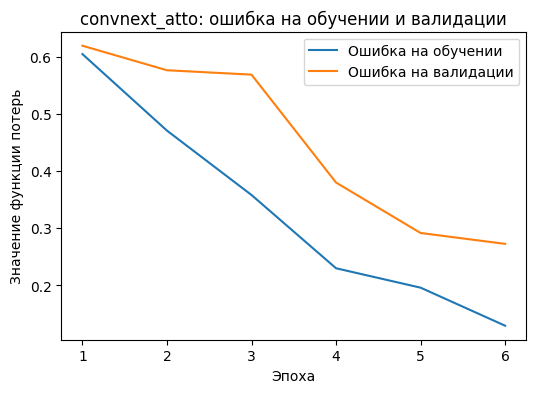

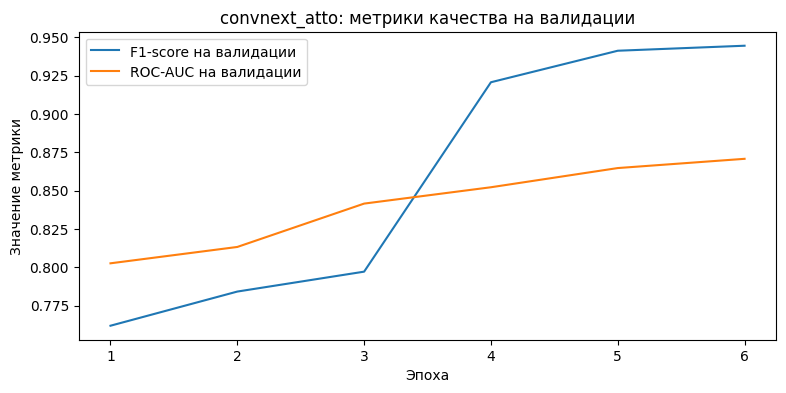

                 precision    recall  f1-score   support

Без повреждений       0.29      0.53      0.37        15
С повреждениями       0.96      0.90      0.93       195

       accuracy                           0.87       210
      macro avg       0.62      0.72      0.65       210
   weighted avg       0.91      0.87      0.89       210



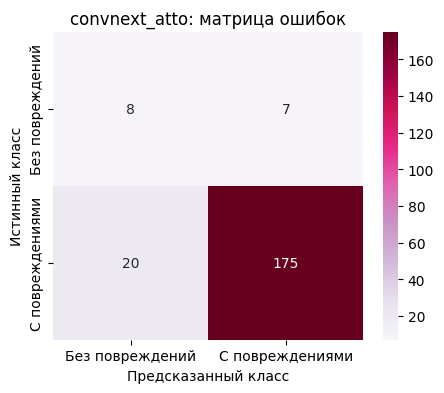

🏃 View run convnext_atto at: https://dagshub.com/RenataMal/GP5.mlflow/#/experiments/0/runs/c176dce92b1a423abc393d9e33534d67
🧪 View experiment at: https://dagshub.com/RenataMal/GP5.mlflow/#/experiments/0


In [163]:
convnext_model, convnext_history_data, convnext_test_metrics = run_cv_experiment_with_freeze(
    model_name=model_name_convnext, 
    model=model_convnext,
    train_loader=train_loader, 
    val_loader=val_loader, 
    test_loader=test_loader, 
    criterion=baseline_criterion, 
    optimizer=convnext_optimizer, 
    device=device, 
    num_epochs=num_epochs, 
    params=convnext_params)

Видно, что дисбаланс классов решился тем, что мы внедрили weightSampler, но есть еще куда двигаться - попробуем модель ConvNext nano, а потом попробуем запустить ее на больших эпохах

In [164]:
model_name_convnext = 'convnext_nano' 
model_convnext = timm.create_model(model_name_convnext, pretrained=True, num_classes=1)

In [ ]:
convnext_model, convnext_history_data, convnext_test_metrics = run_cv_experiment_with_freeze(
    model_name=model_name_convnext, 
    model=model_convnext,
    train_loader=train_loader, 
    val_loader=val_loader, 
    test_loader=test_loader, 
    criterion=baseline_criterion, 
    optimizer=optimizer, 
    device=device, 
    num_epochs=num_epochs, 
    params=convnext_params)